예제 6.15 전이 학습

In [ ]:
# 예제 6.15  VGG16 전이 학습/미세 조정 Cats_and_Dogs

# 셋업
import tensorflow as tf
from tensorflow.keras import Sequential, Model, Input
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.utils import image_dataset_from_directory
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

# 데이터셋 다운로드
url = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
path_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=url, extract=True)
path = os.path.join(os.path.dirname(path_zip), 'cats_and_dogs_filtered')

train_dir = os.path.join(path, 'train')        # 학습 데이터 경로 지정
valid_dir = os.path.join(path, 'validation')   # 검증 데이터 경로 지정

print(os.listdir(train_dir))   # 하위 폴더 확인
print(os.listdir(valid_dir))

68606236/68606236 [==============================] - 0s 0us/step
['cats', 'dogs']
['cats', 'dogs']


size of image: (500, 414)
shape of image: (414, 500, 3)


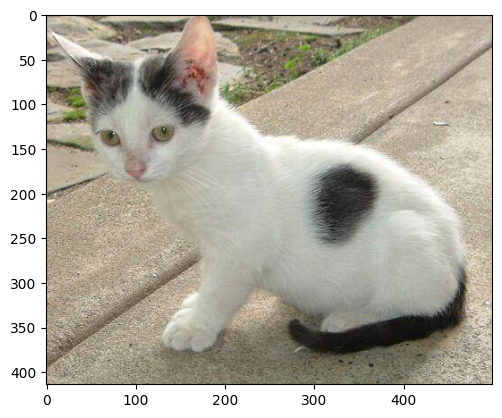

In [ ]:
# 원본 이미지 확인
file_path = os.path.join(train_dir, 'cats', 'cat.3.jpg')   # 파일 경로

with Image.open(file_path) as img:
    print(f"size of image: {img.size}")    # 이미지 크기(가로x세로) 확인
    print(f"shape of image: {np.array(img).shape}")   #이미지 shape 확인

    plt.imshow(img)   # 이미지 출력
    plt.show()

In [ ]:
# 데이터 준비
train_ds = image_dataset_from_directory(train_dir, shuffle=True, batch_size=32,
                                        image_size=(160, 160))
valid_ds = image_dataset_from_directory(valid_dir, shuffle=True, batch_size=32,
                                        image_size=(160, 160))

print(len(train_ds))   # 학습 데이터 크기 확인
print(len(valid_ds))   # 검증 데이터 크기 확인

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
63
32


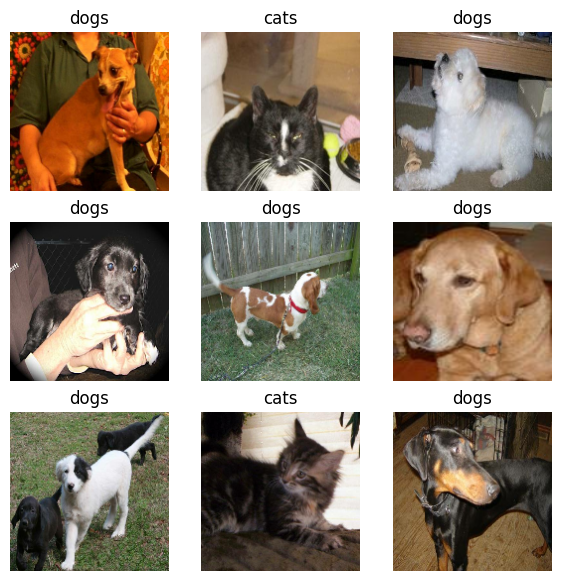

In [ ]:
# 학습 데이터 시각화
class_name = train_ds.class_names       # 클래스명(cats, dogs)

for image, label in train_ds.take(1):   # 레이블(0, 1)
    plt.figure(figsize=(7, 7))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(image[i] / 255)
        plt.title(class_name[label[i]])
        plt.axis("off")

    plt.show()

In [ ]:
# 검증/테스트 데이터 분할
valid_batch = len(valid_ds)
valid_ds = valid_ds.skip(valid_batch // 2)   # 분할 바율 0.5
test_ds = valid_ds.take(valid_batch // 2)

print(f"{len(valid_ds)}")   # 검증 데이터 확인
print(f"{len(test_ds)}")    # 테스트 데이터 확인

16
16


In [ ]:
# 데이터 증강
image_augment = Sequential([
    RandomFlip('horizontal'),   # 수평 뒤집기
    RandomRotation(0.2),        # 회전
    RandomZoom(0.3)             # 확대
])

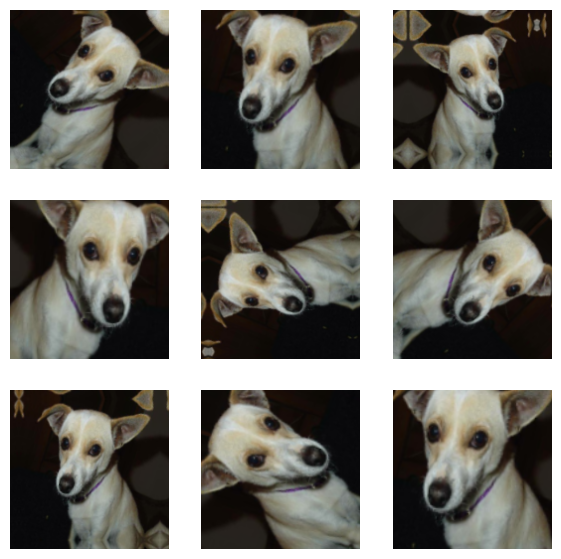

In [ ]:
# 데이터 증강 결과 시각화
for image, _ in train_ds.take(1):
    plt.figure(figsize=(7, 7))

    for i in range(9):
        augmented_image = image_augment(tf.expand_dims(image[0], 0))
                            # (batch_size, height, width, channels)
        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

    plt.show()

In [ ]:
# VGG16 베이스 모델 생성
base_model = VGG16(include_top=False,    # 분류 신경망 포함하지 않음
                   weights='imagenet',   # ImageNet으로 학습한 가중치
                   input_shape=(160, 160, 3))
base_model.trainable = False   # 베이스 모델 동결

base_model.summary()

58889256/58889256 [==============================] - 0s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 160, 160, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 160, 160, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 80, 80, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 80, 80, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 80, 80, 128)       147584    
                                                              

In [ ]:
# 모델 생성
inputs = Input(shape=(160, 160, 3))
x = image_augment(inputs)                     # 데이터 증강
x = preprocess_input(x)                       # 정규화
x = base_model(x)                             # VGG16 베이스 모델
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)          # 은닉층 뉴런 128개
x = Dropout(0.5)(x)                           # 드롭아웃 비율 0.5
outputs = Dense(1, activation='sigmoid')(x)   # 출력층 뉴런 1개

model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 160, 160, 3)       0         
                                                                 
 tf.__operators__.getitem (S  (None, 160, 160, 3)      0         
 licingOpLambda)                                                 
                                                                 
 tf.nn.bias_add (TFOpLambda)  (None, 160, 160, 3)      0         
                                                                 
 vgg16 (Functional)          (None, 5, 5, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                      

In [ ]:
# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# 모델 학습
history = model.fit(train_ds, epochs=10, validation_data=valid_ds)

Epoch 1/10
63/63 [==============================] - 13s 136ms/step - loss: 0.9352 - accuracy: 0.8145 - val_loss: 0.1487 - val_accuracy: 0.9570
Epoch 2/10
63/63 [==============================] - 7s 106ms/step - loss: 0.3150 - accuracy: 0.8895 - val_loss: 0.1373 - val_accuracy: 0.9549
Epoch 3/10
63/63 [==============================] - 6s 99ms/step - loss: 0.2608 - accuracy: 0.9000 - val_loss: 0.1231 - val_accuracy: 0.9488
Epoch 4/10
63/63 [==============================] - 7s 100ms/step - loss: 0.2151 - accuracy: 0.9125 - val_loss: 0.1031 - val_accuracy: 0.9652
Epoch 5/10
63/63 [==============================] - 6s 99ms/step - loss: 0.2082 - accuracy: 0.9150 - val_loss: 0.1036 - val_accuracy: 0.9693
Epoch 6/10
63/63 [==============================] - 7s 115ms/step - loss: 0.1820 - accuracy: 0.9250 - val_loss: 0.1035 - val_accuracy: 0.9611
Epoch 7/10
63/63 [==============================] - 6s 100ms/step - loss: 0.1659 - accuracy: 0.9400 - val_loss: 0.1130 - val_accuracy: 0.9672
Epoch 8

In [ ]:
# 베이스 모델 동결 해제
base_model.trainable = True     # 동결 해제

print(len(base_model.layers))   # 베이스 모델 계층 수 확인

for layer in base_model.layers[:-4]:   # block5 제외하고 동결
  layer.trainable = False

In [ ]:
# 미세 조정 모델 컴파일(학습률 감소)
model.compile(optimizer = Adam(learning_rate=1e-5),
              loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# 미세 조정 모델 학습 콜백 활용
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "transfer_learning_vgg16.h5", save_best_only=True)

history_fine = model.fit(train_ds, validation_data=valid_ds,
                         batch_size=32, epochs=10, verbose=0.
                         callbacks=checkpoint_cb)

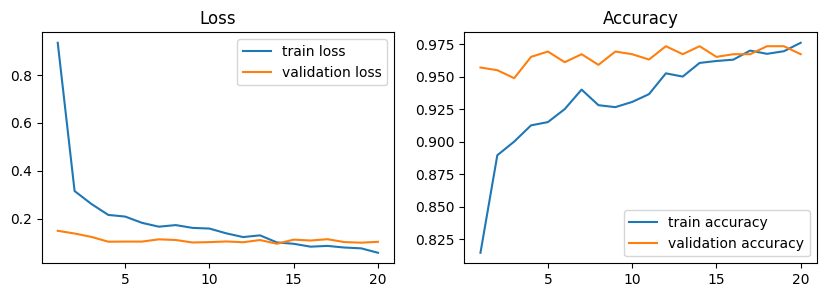

In [ ]:
# 학습 결과 시각화
history.history["loss"] += history_fine.history["loss"]
history.history['val_loss'] += history_fine.history['val_loss']
history.history["accuracy"] += history_fine.history["accuracy"]
history.history['val_accuracy'] += history_fine.history['val_accuracy']

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

ax = axs[0]
ax.plot(range(1, len(history.history["loss"]) + 1),
        history.history['loss'], label='train loss')
ax.plot(range(1, len(history.history["val_loss"]) + 1),
        history.history['val_loss'], label='validation loss')
ax.set_title('Loss')
ax.legend(loc='best')

ax = axs[1]
ax.plot(range(1, len(history.history["accuracy"]) + 1),
        history.history['accuracy'], label='train accuracy')
ax.plot(range(1, len(history.history["val_accuracy"]) + 1),
        history.history['val_accuracy'], label='validation accuracy')
ax.set_title('Accuracy')
ax.legend(loc='best')

plt.show()

In [ ]:
# 모델 평가
model.evaluate(test_ds)

16/16 [==============================] - 2s 72ms/step - loss: 0.1106 - accuracy: 0.9652


[0.1105775460600853, 0.9651639461517334]

Prediction: 
 [0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 1 0]
Label: 
 [1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 1 0]


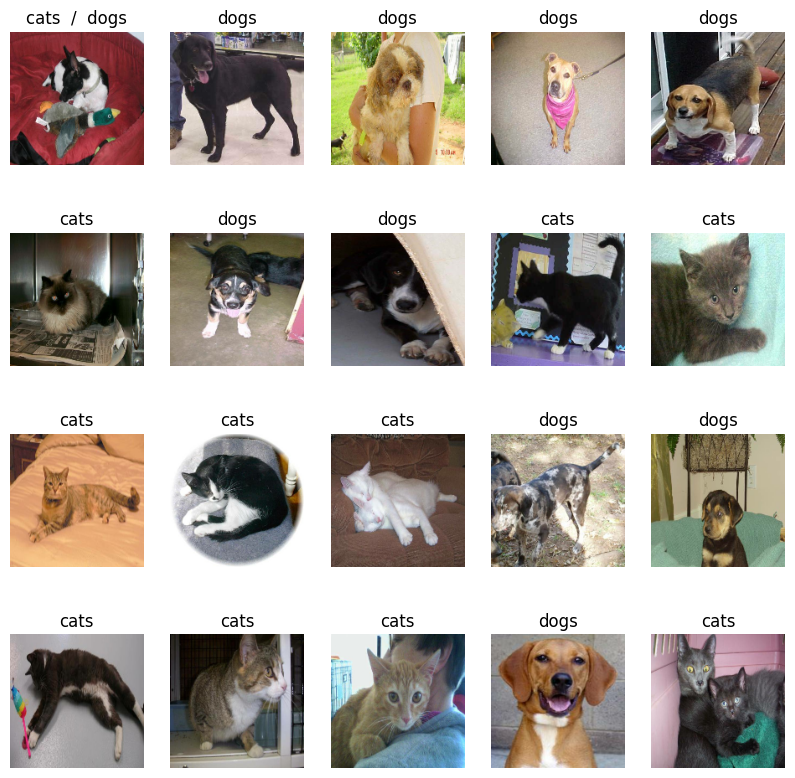

In [ ]:
# 모델 예측 결과 시각화
image, label = next(iter(test_ds))        # 이터레이터 사용하여 배치 가져옴
prediction = model.predict_on_batch(image).reshape(-1)   # 배치 단위로 예측
predict = (prediction >= 0.5).astype(int)   # 임계치 0.5

print(f"Prediction: \n {predict}")
print(f"Label: \n {label}")

plt.figure(figsize=(10, 10))

for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(image[i] / 255)
    if predict[i] != label[i]:
        plt.title(class_name[predict[i]] + '  /  '
                  + class_name[label[i]])
    else:
        plt.title(class_name[predict[i]])
    plt.axis('off')
plt.show()